In [4]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MetaTrader5 as mt5

In [5]:
mt5.initialize()

login = os.environ["FTMO_DEMO_LOGIN"]
password = os.environ["FTMO_DEMO_PASSWORD"]
server = os.environ["FTMO_DEMO_SERVER"]

mt5.login(login=login, password=password, server=server)

False

In [6]:
from_date = datetime(2024,12,28)
to_date = datetime(2024,12,29)
deals = mt5.history_deals_get(from_date, to_date)
df=pd.DataFrame(list(deals),columns=deals[0]._asdict().keys())
df['time'] = pd.to_datetime(df['time'], unit='s')
df

,ticket,order,time,time_msc,type,entry,magic,position_id,reason,volume,price,commission,swap,profit,fee,symbol,comment,external_id
0,187784647,196301294,2024-12-28 18:50:12,1735411812537,1,0,0,196301294,0,0.01,94781.14,0.0,0.0,0.00,0.0,BTCUSD,,101369562
1,187784648,196301295,2024-12-28 18:50:13,1735411813376,0,0,0,196301295,0,0.01,94815.66,0.0,0.0,0.00,0.0,BTCUSD,,101369563
2,187784675,196301322,2024-12-28 18:50:55,1735411855365,0,3,0,196301294,0,0.01,94815.66,0.0,0.0,-0.35,0.0,BTCUSD,#196301294 by #196301295,
3,187784676,196301322,2024-12-28 18:50:55,1735411855365,1,3,0,196301295,0,0.01,94781.14,0.0,0.0,0.00,0.0,BTCUSD,#196301294 by #196301295,
4,187784774,196301422,2024-12-28 18:56:57,1735412217858,0,0,0,196301422,3,0.01,94894.36,0.0,0.0,0.00,0.0,BTCUSD,,101369981
5,187784801,196301452,2024-12-28 18:59:02,1735412342588,0,0,0,196301452,3,0.01,94833.76,0.0,0.0,0.00,0.0,BTCUSD,,101370101
6,187785381,196302033,2024-12-28 19:18:13,1735413493911,1,1,0,196301422,0,0.01,94993.54,0.0,0.0,0.99,0.0,BTCUSD,,101371889
7,187785390,196302043,2024-12-28 19:18:25,1735413505102,0,0,0,196302043,0,0.02,95044.56,0.0,0.0,0.00,0.0,BTCUSD,,101371902
8,187785395,196302048,2024-12-28 19:18:54,1735413534897,1,0,0,196302048,0,0.02,94992.74,0.0,0.0,0.00,0.0,BTCUSD,,101371922
9,187785562,196302239,2024-12-28 19:22:45,1735413765115,1,3,0,196302043,3,0.02,94992.74,0.0,0.0,-1.04,0.0,BTCUSD,#196302043 by #196302048,


In [7]:
profits = df[df['entry']==1]['profit']
profits

6     0.99
12   -0.77
13    2.81
Name: profit, dtype: float64

In [8]:
# Separate wins and losses
wins = profits[profits > 0]
losses = profits[profits < 0]

# Function to detect outliers using IQR
def detect_outliers(data):
    Q1 = np.percentile(data, 25)  # First quartile
    Q3 = np.percentile(data, 75)  # Third quartile
    IQR = Q3 - Q1                # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

# Detect outliers for wins and losses
win_outliers = detect_outliers(wins)
loss_outliers = detect_outliers(losses)

# Metrics calculations
wins_total = wins.sum()
wins_mean = wins.mean()
wins_count = len(wins)

losses_total = losses.sum()
losses_mean = losses.mean()
losses_count = len(losses)

win_loss_ratio = abs(wins_total / losses_total)

# Calculations
summary = {
    "Total W/L": f"{wins_total:.2f} / {losses_total:.2f}",
    "Number of W/L": f"{wins_count} / {losses_count}",
    "Average W/L": f"{wins_mean:.2f} / {losses_mean:.2f}",
    "Win-to-Loss Ratio": f"{win_loss_ratio:.2f}",
    "Win Outliers": list(win_outliers),
    "Loss Outliers": list(loss_outliers)
}

# Print Results
print("Summary Statistics:")
for key, value in summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, (int, float)) else f"{key}: {value}")


Summary Statistics:
Total W/L: 3.80 / -0.77
Number of W/L: 2 / 1
Average W/L: 1.90 / -0.77
Win-to-Loss Ratio: 4.94
Win Outliers: []
Loss Outliers: []


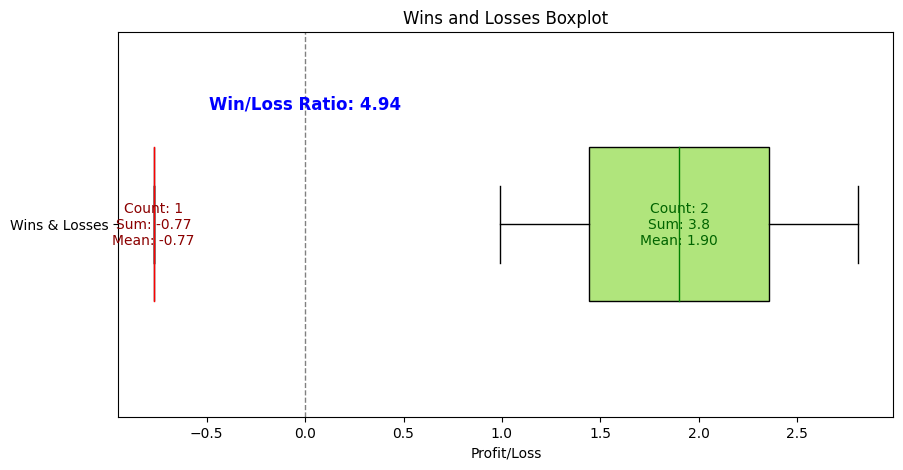

In [9]:
plt.figure(figsize=(10, 5))

# Define soft colors for wins and losses
soft_green = '#b0e57c'  # Light green for wins
soft_red = '#f4a6a6'    # Light red for losses

# Plot Wins and Losses as horizontal boxplots on the same line
plt.boxplot(wins, positions=[1], widths=0.4, vert=False, showfliers=True, patch_artist=True,
            boxprops=dict(facecolor=soft_green, color='black'),
            medianprops=dict(color='green'))
plt.boxplot(losses, positions=[1], widths=0.4, vert=False, showfliers=True, patch_artist=True,
            boxprops=dict(facecolor=soft_red, color='black'),
            medianprops=dict(color='red'))

# Add a vertical dashed line at x=0
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Adding annotations for Wins
plt.text(wins.mean(), 1, f"Count: {wins_count}\nSum: {wins_total}\nMean: {wins_mean:.2f}", ha='center', va='center', color='darkgreen', fontsize=10)

# Adding annotations for Losses
plt.text(losses.mean(), 1, f"Count: {losses_count}\nSum: {losses_total}\nMean: {losses_mean:.2f}", ha='center', va='center', color='darkred', fontsize=10)

# Display Win/Loss Ratio as an annotation
plt.text(0, 1.3, f"Win/Loss Ratio: {win_loss_ratio:.2f}", ha='center', color='blue', fontsize=12, fontweight='bold')

# Customizing the plot
plt.title("Wins and Losses Boxplot")
plt.xlabel("Profit/Loss")
plt.yticks([1], ['Wins & Losses'])  # Single line label

plt.show()